# Tracks AI - LangGraph Workflow

Goal:

Connect all Tracks AI agents into a single workflow.

Flow:

Assessment Agent
↓
Prerequisite Agent
↓
Roadmap Agent
↓
Timeline Planner Agent

In [11]:
from typing import TypedDict

from langgraph.graph import (
    StateGraph,
    START,
    END
)

In [12]:
class TracksAIState(TypedDict):

    skill: str

    assessment_answers: dict

    user_preferences: dict

    assessment_result: dict

    prerequisite_result: dict

    roadmap_result: dict

    timeline_result: dict

In [13]:
def assessment_node(state):

    print("Assessment Agent Running")

    return {

        "assessment_result": {

            "current_level": "Beginner",

            "strengths": [
                "Python Basics"
            ],

            "weaknesses": [
                "Statistics"
            ]
        }
    }

In [14]:
def prerequisite_node(state):

    print("Prerequisite Agent Running")

    return {

        "prerequisite_result": {

            "missing_prerequisites": [
                "Statistics",
                "Linear Algebra"
            ]
        }
    }

In [15]:
def roadmap_node(state):

    print("Roadmap Agent Running")

    return {

        "roadmap_result": {

            "total_phases": 4,

            "title": "AI/ML Roadmap"
        }
    }

In [16]:
def timeline_node(state):

    print("Timeline Planner Running")

    return {

        "timeline_result": {

            "duration_weeks": 20
        }
    }

In [17]:
builder = StateGraph(
    TracksAIState
)

In [18]:
builder.add_node(
    "assessment",
    assessment_node
)

builder.add_node(
    "prerequisite",
    prerequisite_node
)

builder.add_node(
    "roadmap",
    roadmap_node
)

builder.add_node(
    "timeline",
    timeline_node
)

In [19]:
builder.add_edge(
    START,
    "assessment"
)

builder.add_edge(
    "assessment",
    "prerequisite"
)

builder.add_edge(
    "prerequisite",
    "roadmap"
)

builder.add_edge(
    "roadmap",
    "timeline"
)

builder.add_edge(
    "timeline",
    END
)

In [20]:
graph = builder.compile()

In [21]:
print(
    graph.get_graph().draw_mermaid()
)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assessment(assessment)
	prerequisite(prerequisite)
	roadmap(roadmap)
	timeline(timeline)
	__end__([<p>__end__</p>]):::last
	__start__ --> assessment;
	assessment --> prerequisite;
	prerequisite --> roadmap;
	roadmap --> timeline;
	timeline --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



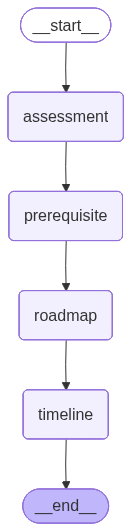

In [22]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [23]:
test_state = {

    "skill": "AI/ML",

    "assessment_answers": {},

    "user_preferences": {}
}

In [24]:
result = graph.invoke(
    test_state
)

result

Assessment Agent Running
Prerequisite Agent Running
Roadmap Agent Running
Timeline Planner Running


{'skill': 'AI/ML',
 'assessment_answers': {},
 'user_preferences': {},
 'assessment_result': {'current_level': 'Beginner',
  'strengths': ['Python Basics'],
  'weaknesses': ['Statistics']},
 'prerequisite_result': {'missing_prerequisites': ['Statistics',
   'Linear Algebra']},
 'roadmap_result': {'total_phases': 4, 'title': 'AI/ML Roadmap'},
 'timeline_result': {'duration_weeks': 20}}